## Session 4: England's Euro 2025 journey

**Guiding questions:**
1. How did England's attacking threat change match by match?
2. Did England deserve their results?
3. Who drove England's attack?
4. How did England defend?
5. Looking ahead: what does the data suggest about England's chances 
   of a third consecutive title at Euro 2029 in Germany?

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch

print("Libraries loaded")

Libraries loaded


In [6]:
matches = sb.matches(competition_id=53, season_id=315)

england = matches[
    matches["home_team"].str.contains("England") |
    matches["away_team"].str.contains("England")
].sort_values("match_date")

england[["match_id", "match_date", "home_team", "home_score", "away_score", "away_team"]]

,match_id,match_date,home_team,home_score,away_score,away_team
27,3998843,2025-07-05,France Women's,2,1,England Women's
18,3998851,2025-07-09,England Women's,4,0,Netherlands Women's
11,3998858,2025-07-13,England Women's,6,1,Wales W
9,4018355,2025-07-17,Sweden Women's,2,2,England Women's
6,4020005,2025-07-22,England Women's,2,1,Italy Women's
4,4020846,2025-07-27,England Women's,1,1,Spain Women's


In [7]:
all_events = []

for match_id in england["match_id"]:
    match_events = sb.events(match_id=match_id)
    all_events.append(match_events)

events = pd.concat(all_events)
events.shape

(22853, 108)

In [8]:
shots = events[(events["type"] == "Shot") & (events["period"] < 5)].copy()
shots["is_goal"] = shots["shot_outcome"] == "Goal"

shots[["match_id", "team", "player", "shot_outcome", "is_goal"]].head()

,match_id,team,player,shot_outcome,is_goal
2945,3998843,England Women's,Lauren James,Off T,False
2946,3998843,France Women's,Selma Bacha,Blocked,False
2947,3998843,France Women's,Oriane Jean-François,Off T,False
2948,3998843,England Women's,Lauren James,Off T,False
2949,3998843,France Women's,Sakina Karchaoui,Off T,False


In [9]:
match_summary = shots.groupby(["match_id", "team"]).agg(
    shots=("shot_statsbomb_xg", "count"),
    xg=("shot_statsbomb_xg", "sum"),
    goals=("is_goal", "sum")
).round(2)

match_summary

shots    xg  goals
match_id team                                   
3998843  England Women's         12  0.73      1
         France Women's          14  1.65      2
3998851  England Women's         17  2.40      4
         Netherlands Women's      4  0.16      0
3998858  England Women's         24  5.39      6
         Wales W                  6  0.63      1
4018355  England Women's         18  1.91      2
         Sweden Women's          13  1.73      2
4020005  England Women's         24  3.05      2
         Italy Women's           11  1.18      1
4020846  England Women's          8  0.88      1
         Spain Women's           23  2.14      1

In [10]:
match_summary = match_summary.reset_index()

eng = match_summary[match_summary["team"].str.contains("England")]
opp = match_summary[~match_summary["team"].str.contains("England")]

journey = eng.merge(opp, on="match_id", suffixes=("_eng", "_opp"))
journey = journey.merge(england[["match_id", "match_date"]], on="match_id").sort_values("match_date")

journey[["match_date", "team_opp", "shots_eng", "shots_opp", "xg_eng", "xg_opp", "goals_eng", "goals_opp"]]

,match_date,team_opp,shots_eng,shots_opp,xg_eng,xg_opp,goals_eng,goals_opp
0,2025-07-05,France Women's,12,14,0.73,1.65,1,2
1,2025-07-09,Netherlands Women's,17,4,2.40,0.16,4,0
2,2025-07-13,Wales W,24,6,5.39,0.63,6,1
3,2025-07-17,Sweden Women's,18,13,1.91,1.73,2,2
4,2025-07-22,Italy Women's,24,11,3.05,1.18,2,1
5,2025-07-27,Spain Women's,8,23,0.88,2.14,1,1


In [11]:
journey["opponent"] = journey["team_opp"].str.replace(r" (Women's|W)$", "", regex=True)
journey["stage"] = ["Group", "Group", "Group", "Quarter-final", "Semi-final", "Final"]
journey["label"] = journey["stage"] + "\n" + journey["opponent"]

journey[["label", "xg_eng", "xg_opp"]]

,label,xg_eng,xg_opp
0,Group\nFrance,0.73,1.65
1,Group\nNetherlands,2.40,0.16
2,Group\nWales,5.39,0.63
3,Quarter-final\nSweden,1.91,1.73
4,Semi-final\nItaly,3.05,1.18
5,Final\nSpain,0.88,2.14


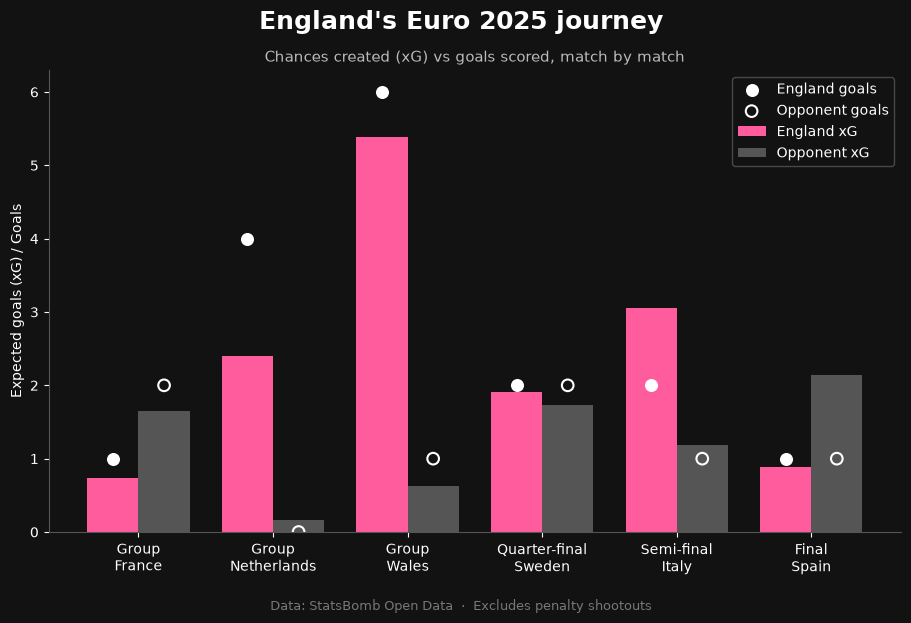

In [12]:
import numpy as np

x = np.arange(len(journey))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

# xG bars: England and opponent side by side
ax.bar(x - width/2, journey["xg_eng"], width, color="#FF5C9D", label="England xG")
ax.bar(x + width/2, journey["xg_opp"], width, color="#555555", label="Opponent xG")

# Actual goals as dots on top
ax.scatter(x - width/2, journey["goals_eng"], color="white", s=70, zorder=3,
           label="England goals")
ax.scatter(x + width/2, journey["goals_opp"], facecolors="none", edgecolors="white",
           s=70, linewidths=1.5, zorder=3, label="Opponent goals")

# Axes styling
ax.set_xticks(x)
ax.set_xticklabels(journey["label"], color="white")
ax.set_ylabel("Expected goals (xG) / Goals", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

# Titles and credit
fig.suptitle("England's Euro 2025 journey", color="white", fontsize=18, fontweight="bold")
ax.set_title("Chances created (xG) vs goals scored, match by match", color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.02, "Data: StatsBomb Open Data  ·  Excludes penalty shootouts",
         color="#777777", fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
fig.savefig("england_journey_xg.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

In [13]:
journey["opponent"] = journey["team_opp"].str.replace(r" (Women's|W)$", "", regex=True)
journey["stage"] = ["Group", "Group", "Group", "Quarter-final", "Semi-final", "Final"]
journey["pens"] = ["", "", "", " (won on pens)", "", " (won on pens)"]

journey["score"] = (journey["goals_eng"].astype(int).astype(str) + "–"
                    + journey["goals_opp"].astype(int).astype(str) + journey["pens"])

journey["label"] = journey["stage"] + "\n" + journey["opponent"] + "\n" + journey["score"]

journey[["label"]]

,label
0,Group\nFrance\n1–2
1,Group\nNetherlands\n4–0
2,Group\nWales\n6–1
3,Quarter-final\nSweden\n2–2 (won on pens)
4,Semi-final\nItaly\n2–1
5,Final\nSpain\n1–1 (won on pens)


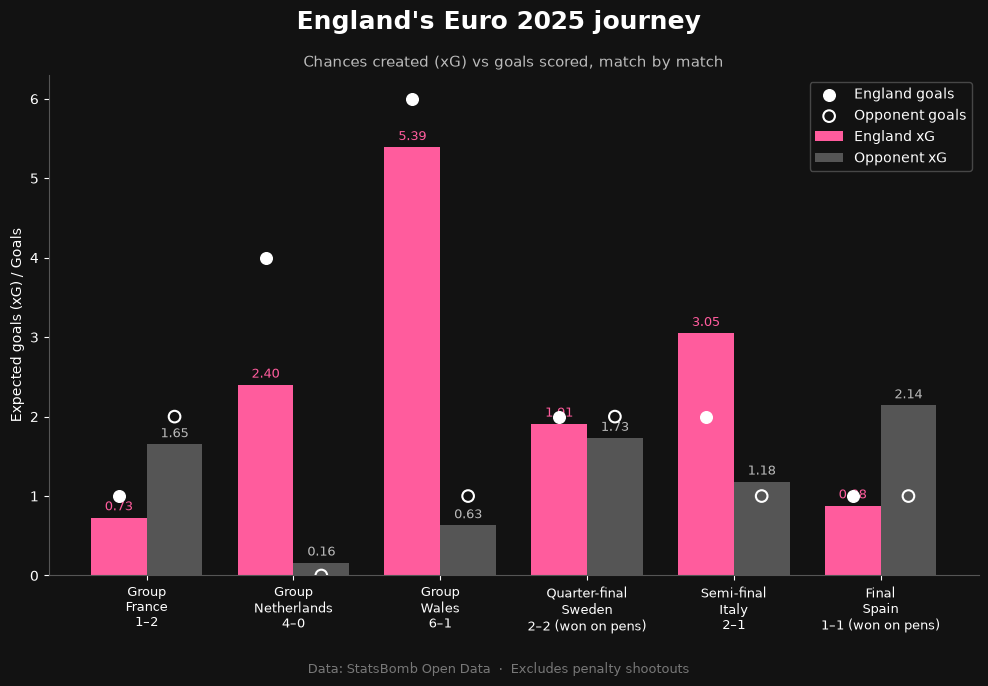

In [14]:
import numpy as np

x = np.arange(len(journey))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

# xG bars: England and opponent side by side
bars_eng = ax.bar(x - width/2, journey["xg_eng"], width, color="#FF5C9D", label="England xG")
bars_opp = ax.bar(x + width/2, journey["xg_opp"], width, color="#555555", label="Opponent xG")

# xG values above each bar
ax.bar_label(bars_eng, fmt="%.2f", color="#FF5C9D", fontsize=9, padding=3)
ax.bar_label(bars_opp, fmt="%.2f", color="#BBBBBB", fontsize=9, padding=3)

# Actual goals as dots
ax.scatter(x - width/2, journey["goals_eng"], color="white", s=70, zorder=3,
           label="England goals")
ax.scatter(x + width/2, journey["goals_opp"], facecolors="none", edgecolors="white",
           s=70, linewidths=1.5, zorder=3, label="Opponent goals")

# Axes styling
ax.set_xticks(x)
ax.set_xticklabels(journey["label"], color="white", fontsize=9)
ax.set_ylabel("Expected goals (xG) / Goals", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

# Titles and credit
fig.suptitle("England's Euro 2025 journey", color="white", fontsize=18, fontweight="bold")
ax.set_title("Chances created (xG) vs goals scored, match by match", color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.04, "Data: StatsBomb Open Data  ·  Excludes penalty shootouts",
         color="#777777", fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
fig.savefig("england_journey_xg.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

In [15]:
# xG with actual goals in brackets, above each bar
eng_labels = [f"{xg:.2f} ({int(g)})" for xg, g in zip(journey["xg_eng"], journey["goals_eng"])]
opp_labels = [f"{xg:.2f} ({int(g)})" for xg, g in zip(journey["xg_opp"], journey["goals_opp"])]

ax.bar_label(bars_eng, labels=eng_labels, color="#FF5C9D", fontsize=9, padding=3)
ax.bar_label(bars_opp, labels=opp_labels, color="#BBBBBB", fontsize=9, padding=3)

[Text(0, 3, '1.65 (2)'),
 Text(0, 3, '0.16 (0)'),
 Text(0, 3, '0.63 (1)'),
 Text(0, 3, '1.73 (2)'),
 Text(0, 3, '1.18 (1)'),
 Text(0, 3, '2.14 (1)')]

In [16]:
ax.set_title("Bar labels show xG (actual goals in brackets)", color="#BBBBBB", fontsize=11)

Text(0.5, 1.0, 'Bar labels show xG (actual goals in brackets)')

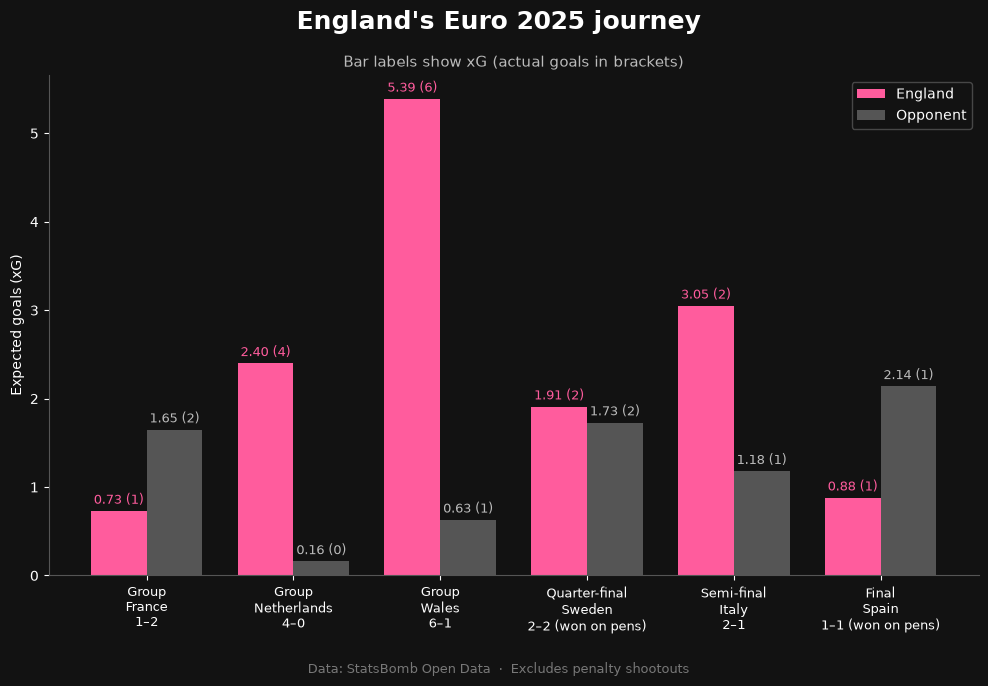

In [17]:
import numpy as np

x = np.arange(len(journey))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

# xG bars: England and opponent side by side
bars_eng = ax.bar(x - width/2, journey["xg_eng"], width, color="#FF5C9D", label="England")
bars_opp = ax.bar(x + width/2, journey["xg_opp"], width, color="#555555", label="Opponent")

# xG with actual goals in brackets, above each bar
eng_labels = [f"{xg:.2f} ({int(g)})" for xg, g in zip(journey["xg_eng"], journey["goals_eng"])]
opp_labels = [f"{xg:.2f} ({int(g)})" for xg, g in zip(journey["xg_opp"], journey["goals_opp"])]

ax.bar_label(bars_eng, labels=eng_labels, color="#FF5C9D", fontsize=9, padding=3)
ax.bar_label(bars_opp, labels=opp_labels, color="#BBBBBB", fontsize=9, padding=3)

# Axes styling
ax.set_xticks(x)
ax.set_xticklabels(journey["label"], color="white", fontsize=9)
ax.set_ylabel("Expected goals (xG)", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

# Titles and credit
fig.suptitle("England's Euro 2025 journey", color="white", fontsize=18, fontweight="bold")
ax.set_title("Bar labels show xG (actual goals in brackets)", color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.04, "Data: StatsBomb Open Data  ·  Excludes penalty shootouts",
         color="#777777", fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
fig.savefig("england_journey_xg.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()